# Discrete Operators

With fields placed on the staggered grid from the [previous chapter](arakawa_cgrid.ipynb), the differential operators of fluid dynamics become **finite differences and averages that move fields between stagger positions**. This chapter walks through the four operator families finitevolX provides — differences, interpolations, advection, and the Laplacian — and shows each one mapping a field from one set of grid points to another {cite}`durran2010numerical,leveque2002finite`.

**What you will learn**

- How `Difference2D` builds gradients, divergence, and curl as stagger-changing differences
- How `Interpolation2D` averages fields between stagger positions
- How `Advection2D` reconstructs fluxes with upwind / WENO schemes
- How the Laplacian assembles into the elliptic operators the models invert

## The stagger-changing rule

The defining feature of C-grid operators is that **a derivative changes the stagger**. A centred difference of a T-point field along $x$ naturally lives on the U-points half a cell away:

```{math}
:label: ops-diff-x
\big(\partial_x h\big)_{j,\,i+\frac12} \;\approx\; \frac{h_{j,i+1} - h_{j,i}}{\Delta x},
```

which is exactly the `T → U` map. Likewise $\partial_y$ of a T-field lands on V-points (`T → V`). The divergence of a velocity reverses this — it consumes face-staggered fluxes and returns a centred tendency,

```{math}
:label: ops-divergence
\big(\nabla\cdot\mathbf{u}\big)_{j,i} \;\approx\;
  \frac{u_{j,\,i+\frac12} - u_{j,\,i-\frac12}}{\Delta x}
  + \frac{v_{j+\frac12,\,i} - v_{j-\frac12,\,i}}{\Delta y},
```

i.e. `(U, V) → T`. Because the same face values that the divergence consumes are the ones the gradient produces, the discrete divergence is the negative adjoint of the discrete gradient — the property that gives C-grid schemes their clean energy budgets {cite}`arakawa1977computational`.

In [1]:
import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import importlib.util
from pathlib import Path

import finitevolx as fvx
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p numpy,jax,finitevolx,somax")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

watermark extension not installed; skipping reproducibility readout.


## Setup: a smooth test field

We build a 64×64 grid and a smooth, analytically-differentiable test field
$\psi(x,y) = \sin(2\pi x)\cos(2\pi y)$ so we can compare the discrete
operators against their exact continuous counterparts.

In [3]:
grid = fvx.CartesianGrid2D.from_interior(nx_interior=64, ny_interior=64, Lx=1.0, Ly=1.0)
diff = fvx.Difference2D(grid=grid, mask=None)
interp = fvx.Interpolation2D(grid=grid, mask=None)
advection = fvx.Advection2D(grid=grid, mask=None)

x = jnp.linspace(0.0, 1.0, grid.Nx)
y = jnp.linspace(0.0, 1.0, grid.Ny)
xx, yy = jnp.meshgrid(x, y)
psi = jnp.sin(2 * jnp.pi * xx) * jnp.cos(2 * jnp.pi * yy)
print("test field psi:", psi.shape)

test field psi: (66, 66)


## Differences: gradient, divergence, curl

`Difference2D` names each method by the stagger map it performs, so the code
reads like {eq}`ops-diff-x`–{eq}`ops-divergence`. The exact $x$-derivative of
$\psi$ is $2\pi\cos(2\pi x)\cos(2\pi y)$; the discrete `diff_x_T_to_U` should
reproduce it (up to the half-cell shift and truncation error).

In [4]:
dpsi_dx = diff.diff_x_T_to_U(psi)  # T -> U
dpsi_dy = diff.diff_y_T_to_V(psi)  # T -> V

# A divergence of a (u, v) pair returns to T-points.
u = diff.diff_x_T_to_U(psi)
v = diff.diff_y_T_to_V(psi)
div = diff.divergence(u, v)  # (U, V) -> T

# Curl (relative vorticity) of a velocity lands on the corner X-points.
zeta = diff.curl(u, v)  # (U, V) -> X

# Laplacian maps T -> T (used by the elliptic solvers, last section).
lap = diff.laplacian(psi)

for name, field in [
    ("diff_x_T_to_U", dpsi_dx),
    ("diff_y_T_to_V", dpsi_dy),
    ("divergence (U,V->T)", div),
    ("curl (U,V->X)", zeta),
    ("laplacian (T->T)", lap),
]:
    print(f"{name:24s}: shape {field.shape}")

diff_x_T_to_U           : shape (66, 66)
diff_y_T_to_V           : shape (66, 66)
divergence (U,V->T)     : shape (66, 66)
curl (U,V->X)           : shape (66, 66)
laplacian (T->T)        : shape (66, 66)


{numref}`ops-difference-fig` shows the field and its discrete $x$-derivative
side by side with the exact derivative. The discrete operator tracks the
analytic one across the interior; the agreement is the evidence that the
stagger map in {eq}`ops-diff-x` is faithful.

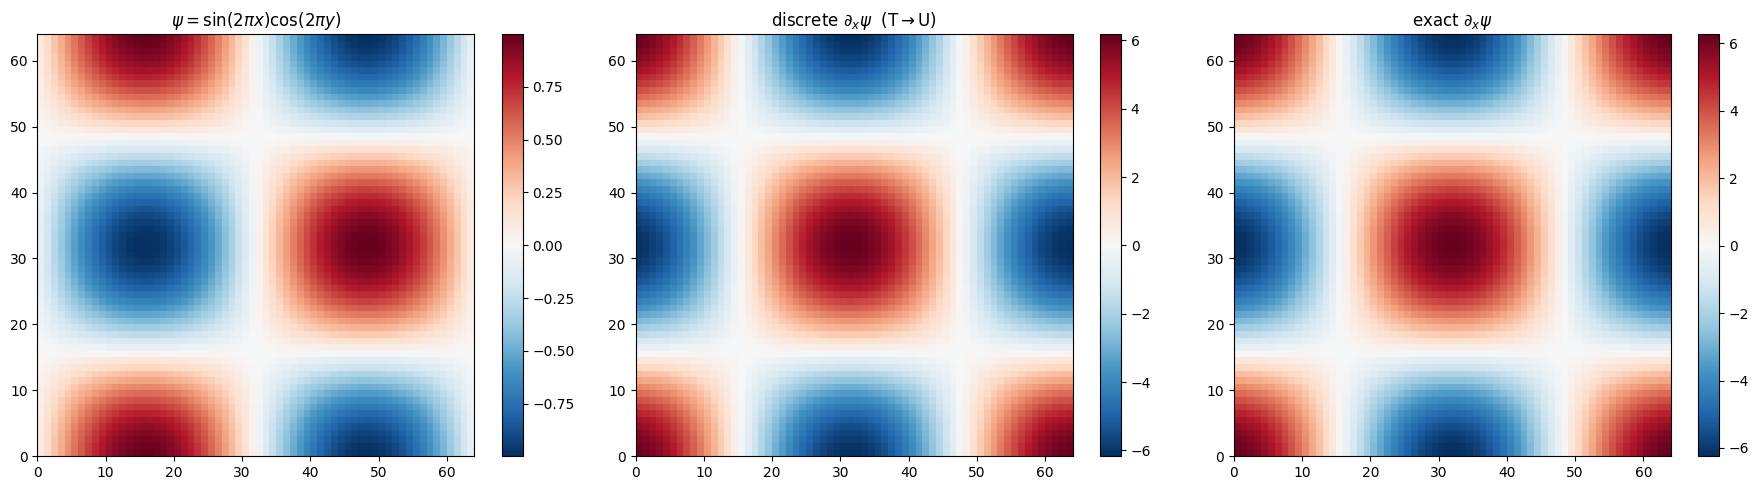

In [5]:
IMG_DIR = Path.cwd().parent / "images" / "operators"
IMG_DIR.mkdir(parents=True, exist_ok=True)

s = (slice(1, -1), slice(1, -1))
exact_dx = 2 * jnp.pi * jnp.cos(2 * jnp.pi * xx) * jnp.cos(2 * jnp.pi * yy)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
im0 = axes[0].pcolormesh(psi[s], cmap="RdBu_r")
axes[0].set(title=r"$\psi = \sin(2\pi x)\cos(2\pi y)$")
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].pcolormesh(dpsi_dx[s], cmap="RdBu_r")
axes[1].set(title=r"discrete $\partial_x \psi$  (T$\to$U)")
fig.colorbar(im1, ax=axes[1])
im2 = axes[2].pcolormesh(exact_dx[s], cmap="RdBu_r")
axes[2].set(title=r"exact $\partial_x \psi$")
fig.colorbar(im2, ax=axes[2])
fig.tight_layout()
fig.savefig(IMG_DIR / "difference_x.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/operators/difference_x.png
:label: ops-difference-fig
:width: 100%

A smooth test field (left), its discrete $x$-derivative from
`diff_x_T_to_U` (centre), and the exact analytic derivative (right). The
discrete C-grid difference reproduces the continuous gradient across the
interior.
```

## Interpolations: moving between stagger positions

Many terms mix fields from different stagger positions — the mass flux $h\,u$
needs $h$ (a T-field) evaluated at the U-points where $u$ lives.
`Interpolation2D` provides the averaging maps, named by the same
source-to-target convention as the differences. The methods are summarised in
{numref}`ops-interp-table`.

```{list-table} A representative set of Interpolation2D averaging maps. Every map is a local average; the name encodes the source-to-target stagger.
:header-rows: 1
:label: ops-interp-table

* - Method
  - Map
  - Use
* - `T_to_U`, `T_to_V`
  - centre to face
  - thickness at velocity points (mass flux $h\,u$)
* - `U_to_T`, `V_to_T`
  - face to centre
  - kinetic energy $\tfrac12(u^2+v^2)$ at T
* - `T_to_X`
  - centre to corner
  - thickness at the vorticity point (potential vorticity)
* - `X_to_U`, `X_to_V`
  - corner to face
  - vorticity flux in the momentum equation
```

In [6]:
h_on_u = interp.T_to_U(psi)  # T -> U
h_on_x = interp.T_to_X(psi)  # T -> X
u_on_t = interp.U_to_T(u)  # U -> T
print(f"T_to_U: {h_on_u.shape}   T_to_X: {h_on_x.shape}   U_to_T: {u_on_t.shape}")

T_to_U: (66, 66)   T_to_X: (66, 66)   U_to_T: (66, 66)


## Advection: upwind and WENO reconstruction

The nonlinear transport term $\nabla\cdot(h\,\mathbf{u})$ in {eq}`ops-divergence`
is where numerical schemes earn their keep: a naive centred flux is
dispersive and produces oscillations at sharp fronts. `Advection2D`
reconstructs the face fluxes with an upwind-biased stencil. The first-order
`upwind1` is maximally diffusive (robust but smearing); the fifth-order
`weno5` (weighted essentially non-oscillatory) is high-order in smooth
regions yet suppresses oscillations near discontinuities by adaptively
weighting its candidate stencils {cite}`liu1994weighted,shu1998essentially`.

upwind1 tendency: (66, 66)   weno5 tendency: (66, 66)


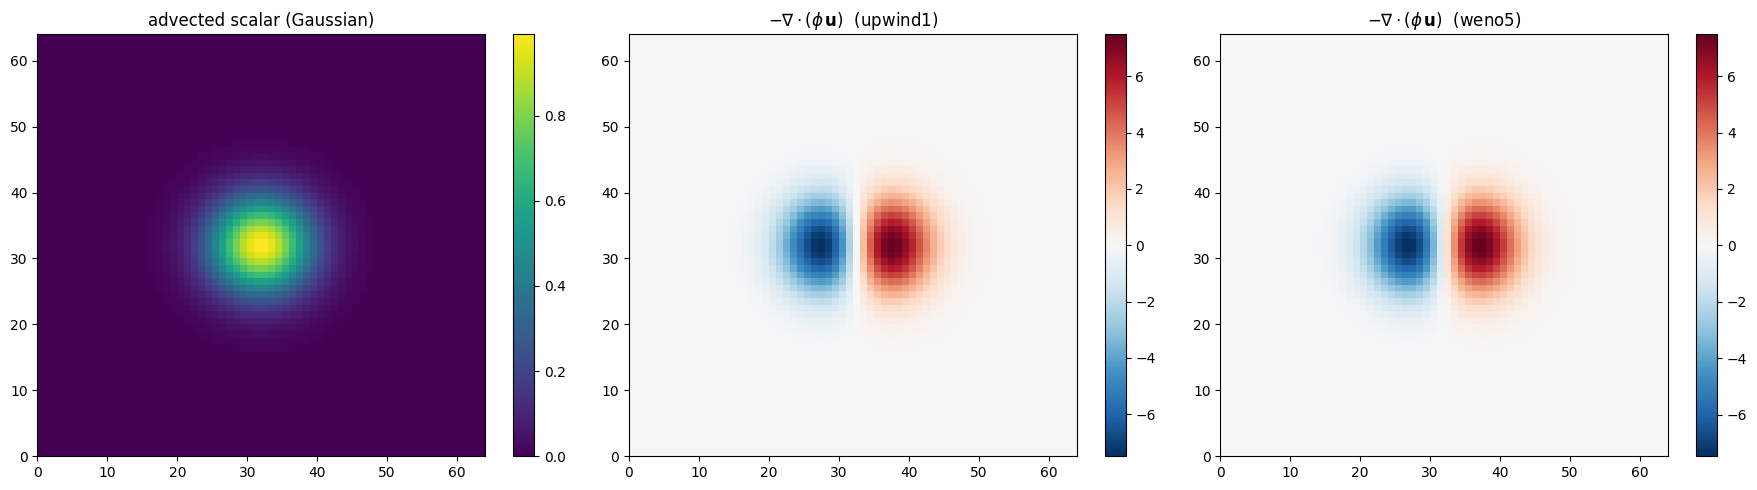

In [7]:
# Advect a Gaussian blob by a uniform flow and compare reconstructions.
blob = jnp.exp(-80.0 * ((xx - 0.5) ** 2 + (yy - 0.5) ** 2))
u_flow = jnp.ones((grid.Ny, grid.Nx))
v_flow = jnp.zeros((grid.Ny, grid.Nx))

tend_upwind = advection(blob, u_flow, v_flow, method="upwind1")
tend_weno = advection(blob, u_flow, v_flow, method="weno5")
print(f"upwind1 tendency: {tend_upwind.shape}   weno5 tendency: {tend_weno.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
im0 = axes[0].pcolormesh(blob[s], cmap="viridis")
axes[0].set(title="advected scalar (Gaussian)")
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].pcolormesh(tend_upwind[s], cmap="RdBu_r")
axes[1].set(title=r"$-\nabla\cdot(\phi\,\mathbf{u})$  (upwind1)")
fig.colorbar(im1, ax=axes[1])
im2 = axes[2].pcolormesh(tend_weno[s], cmap="RdBu_r")
axes[2].set(title=r"$-\nabla\cdot(\phi\,\mathbf{u})$  (weno5)")
fig.colorbar(im2, ax=axes[2])
fig.tight_layout()
fig.savefig(IMG_DIR / "advection_reconstruction.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/operators/advection_reconstruction.png
:label: ops-advection-fig
:width: 100%

The advective tendency $-\nabla\cdot(\phi\,\mathbf{u})$ of a Gaussian scalar
under uniform rightward flow, computed with first-order upwind (centre) and
fifth-order WENO (right). WENO resolves the leading and trailing edges far
more sharply for the same grid.
```

## From the Laplacian to elliptic inversion

The Laplacian `diff.laplacian` (a `T → T` map) is the building block of the
**elliptic problems** the geophysical models solve at every step: recovering
the streamfunction from vorticity, $\nabla^2\psi = \zeta$, or the pressure
from divergence. somax wraps these in dedicated spectral / multigrid solvers
(the Helmholtz and Poisson solvers used by the QG and Navier–Stokes models),
but they all rest on this discrete second-difference operator.

In [8]:
# Round-trip sanity: laplacian of sin/cos returns -8 pi^2 * psi analytically.
lap_psi = diff.laplacian(psi)
exact_lap = -8.0 * jnp.pi**2 * psi
rel_err = float(
    jnp.linalg.norm((lap_psi - exact_lap)[s]) / jnp.linalg.norm(exact_lap[s])
)
print(f"||laplacian(psi) - exact|| / ||exact|| (interior) = {rel_err:.3e}")

||laplacian(psi) - exact|| / ||exact|| (interior) = 3.129e-02


## Summary

- C-grid operators are **stagger-changing**: a derivative of a T-field lands on faces ({eq}`ops-diff-x`), a divergence of faces returns to centres ({eq}`ops-divergence`).
- `Difference2D` provides gradients, `divergence`, `curl`, and `laplacian`; `Interpolation2D` moves fields between positions ({numref}`ops-interp-table`); `Advection2D` reconstructs fluxes with upwind or WENO schemes ({numref}`ops-advection-fig`).
- The discrete Laplacian underlies the elliptic solvers the QG and Navier–Stokes models invert each step.

The next chapter, [boundary conditions](boundary_conditions.ipynb), shows how the ghost halo carries the boundary data these operators read at the domain edge.

## References

```{bibliography}
:filter: docname in docnames
```